In [1]:
import astropy.io.fits as pf
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import os
import subprocess
import importlib as imp
import copy
import scipy.stats
from matplotlib.pyplot import cm
from scipy.stats import kde
import figure_subroutines as subs
from astropy import units as u
from astropy.coordinates import SkyCoord
from pylab import *
from matplotlib import ticker

In [2]:
fieldnames = ["q5","q6","q8","q9","r0","r1","r3","r4","r5","r6","r7","r8","r9"]

numname = np.size(fieldnames)

fieldandband = []

for i in range(0,numname):
    fieldandband.append(fieldnames[i]+'_aq')
    fieldandband.append(fieldnames[i]+'_au')
    fieldandband.append(fieldnames[i]+'_bq')
    fieldandband.append(fieldnames[i]+'_bu')
    fieldandband.append(fieldnames[i]+'_cq')
    fieldandband.append(fieldnames[i]+'_cu')
    fieldandband.append(fieldnames[i]+'_dq')
    fieldandband.append(fieldnames[i]+'_du')

print(fieldandband)

numfields = np.size(fieldandband)
print(numfields)

['q5_aq', 'q5_au', 'q5_bq', 'q5_bu', 'q5_cq', 'q5_cu', 'q5_dq', 'q5_du', 'q6_aq', 'q6_au', 'q6_bq', 'q6_bu', 'q6_cq', 'q6_cu', 'q6_dq', 'q6_du', 'q8_aq', 'q8_au', 'q8_bq', 'q8_bu', 'q8_cq', 'q8_cu', 'q8_dq', 'q8_du', 'q9_aq', 'q9_au', 'q9_bq', 'q9_bu', 'q9_cq', 'q9_cu', 'q9_dq', 'q9_du', 'r0_aq', 'r0_au', 'r0_bq', 'r0_bu', 'r0_cq', 'r0_cu', 'r0_dq', 'r0_du', 'r1_aq', 'r1_au', 'r1_bq', 'r1_bu', 'r1_cq', 'r1_cu', 'r1_dq', 'r1_du', 'r3_aq', 'r3_au', 'r3_bq', 'r3_bu', 'r3_cq', 'r3_cu', 'r3_dq', 'r3_du', 'r4_aq', 'r4_au', 'r4_bq', 'r4_bu', 'r4_cq', 'r4_cu', 'r4_dq', 'r4_du', 'r5_aq', 'r5_au', 'r5_bq', 'r5_bu', 'r5_cq', 'r5_cu', 'r5_dq', 'r5_du', 'r6_aq', 'r6_au', 'r6_bq', 'r6_bu', 'r6_cq', 'r6_cu', 'r6_dq', 'r6_du', 'r7_aq', 'r7_au', 'r7_bq', 'r7_bu', 'r7_cq', 'r7_cu', 'r7_dq', 'r7_du', 'r8_aq', 'r8_au', 'r8_bq', 'r8_bu', 'r8_cq', 'r8_cu', 'r8_dq', 'r8_du', 'r9_aq', 'r9_au', 'r9_bq', 'r9_bu', 'r9_cq', 'r9_cu', 'r9_dq', 'r9_du']
104


In [3]:
C_initial_files = []
C_feather_files = []
G_initial_files = []
G_matched_files = []
G_feather_files = []
Gu_files = []
Gv_files = []
Cu_files = []
Cv_files = []
uv_delt = np.zeros([numfields])

for i in range(0,numfields):
    
    step_files = ['../../GMIMS_CGPS_OB_RW/THESIS_pics/G_initial_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/G_matched_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/G_feather_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/C_initial_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/C_feather_uv_'+fieldandband[i]+'.fits']
    
    field = fits.open(step_files[3])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    C_initial_files.append(data)
    del field
    
    field = fits.open(step_files[4])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    C_feather_files.append(data)
    del field

    u,v = subs.make_axis_lists_2D(hdr)
    Cu_files.append(u)
    Cv_files.append(v)
    
    field = fits.open(step_files[0])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_initial_files.append(data)
    del field
    
    field = fits.open(step_files[1])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_matched_files.append(data)
    del field
    
    field = fits.open(step_files[2])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_feather_files.append(data)
    del field
    
    u,v = subs.make_axis_lists_2D(hdr)
    Gu_files.append(u)
    Gv_files.append(v)
    
    uv_delt[i] = hdr['CDELT2']
    print(i,fieldandband[i],uv_delt[i])

(0, 'q5_aq', 4.2913556)
(1, 'q5_au', 4.2913556)
(2, 'q5_bq', 4.2704163)
(3, 'q5_bu', 4.2704163)
(4, 'q5_cq', 4.2297368)
(5, 'q5_cu', 4.2297368)
(6, 'q5_dq', 4.209393)
(7, 'q5_du', 4.209393)
(8, 'q6_aq', 4.2913556)
(9, 'q6_au', 4.2913556)
(10, 'q6_bq', 4.2704163)
(11, 'q6_bu', 4.2704163)
(12, 'q6_cq', 4.2297368)
(13, 'q6_cu', 4.2297368)
(14, 'q6_dq', 4.209393)
(15, 'q6_du', 4.209393)
(16, 'q8_aq', 4.2913556)
(17, 'q8_au', 4.2913556)
(18, 'q8_bq', 4.2704163)
(19, 'q8_bu', 4.2704163)
(20, 'q8_cq', 4.2297368)
(21, 'q8_cu', 4.2297368)
(22, 'q8_dq', 4.209393)
(23, 'q8_du', 4.209393)
(24, 'q9_aq', 4.2913556)
(25, 'q9_au', 4.2913556)
(26, 'q9_bq', 4.2704163)
(27, 'q9_bu', 4.2704163)
(28, 'q9_cq', 4.2297368)
(29, 'q9_cu', 4.2297368)
(30, 'q9_dq', 4.209393)
(31, 'q9_du', 4.209393)
(32, 'r0_aq', 4.2913556)
(33, 'r0_au', 4.2913556)
(34, 'r0_bq', 4.2704163)
(35, 'r0_bu', 4.2704163)
(36, 'r0_cq', 4.2297368)
(37, 'r0_cu', 4.2297368)
(38, 'r0_dq', 4.209393)
(39, 'r0_du', 4.209393)
(40, 'r1_aq', 4.2913

In [4]:
ampl_G_initial = []
ampl_G_match = []
ampl_G_feath = []
ampl_C_initial = []
ampl_C_feath = []

radius_G_fields = []
radius_C_fields = []

for k in range(0,numfields):

    #=============== SA initial ======================================
    ampl_G_initial.append(G_initial_files[k][1:512,0:257])
    #print(ampl_G_initial[i][0,0])
    #print(ampl_G_initial[i][511,0])
    #print(ampl_G_initial[i][1022,0])
    #print(ampl_G_initial[i].shape)
    #print('')
    #=============== SA matched ======================================
    ampl_G_match.append(G_matched_files[k][1:512,0:257])
    #print(ampl_G_match[i][0,0])
    #print(ampl_G_match[i][511,0])
    #print(ampl_G_match[i][1022,0])
    #print(ampl_G_match[i].shape)
    #print('')
    #=============== SA feathered ======================================
    ampl_G_feath.append(G_feather_files[k][1:512,0:257])
    #print(ampl_G_feath[i][0,0])
    #print(ampl_G_feath[i][511,0])
    #print(ampl_G_feath[i][1022,0])
    #print(ampl_G_feath[i].shape)
    #print('')
    #=============== ST initial ======================================
    ampl_C_initial.append(C_initial_files[k][1:512,0:257])
    #print(ampl_C_initial[i][0,0])
    #print(ampl_C_initial[i][511,0])
    #print(ampl_C_initial[i][1022,0])
    #print(ampl_C_initial[i].shape)
    #print('')
    #=============== ST feathered ======================================
    ampl_C_feath.append(C_feather_files[k][1:512,0:257])
    #print(ampl_C_feath[i][0,0])
    #print(ampl_C_feath[i][511,0])
    #print(ampl_C_feath[i][1022,0])
    #print(ampl_C_feath[i].shape)
    #print('')

    radius_C = np.zeros([511,257])
    radius_G = np.zeros([511,257])
    
    u_G = np.flip(Gu_files[k][1:258],axis=0)
    v_G = Gv_files[k][1:512]
    u_C = np.flip(Cu_files[k][1:258],axis=0)
    v_C = Cv_files[k][1:512]
    print(k)
    #print(np.min(u_C), np.max(u_C), u_C.shape)
    #print(np.min(v_C), np.max(v_C), v_C.shape)
    #print(np.min(u_G), np.max(u_G), u_G.shape)
    #print(np.min(v_G), np.max(v_G), v_G.shape)
    #print('')
    
    for i in range(0,257):
        for j in range(0,511):
            radius_G[j,i] = np.sqrt((u_G[i])**2+(v_G[j])**2)
            radius_C[j,i] = np.sqrt((u_C[i])**2+(v_C[j])**2)
    
    radius_C_fields.append(radius_C)
    radius_G_fields.append(radius_G)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103


In [5]:
SA_orig_samples = np.zeros([numfields,50])
SA_match_samples = np.zeros([numfields,50])
SA_feath_samples = np.zeros([numfields,50])
ST_orig_samples = np.zeros([numfields,50])
ST_feath_samples = np.zeros([numfields,50])
rad_samples = np.zeros([numfields,50])

for j in range(0,numfields):
    print(j)
    rad_samples[j,:] = np.unique(radius_C_fields[j])[0:50]
    for i in range(0,50):
        wx = np.where((radius_C_fields[j]==rad_samples[j,i]))[1]
        wy = np.where((radius_C_fields[j]==rad_samples[j,i]))[0]
        SA_orig_samples[j,i] = np.mean(ampl_G_initial[j][wy,wx])
        SA_match_samples[j,i] = np.mean(ampl_G_match[j][wy,wx])
        SA_feath_samples[j,i] = np.mean(ampl_G_feath[j][wy,wx])
        ST_orig_samples[j,i] = np.mean(ampl_C_initial[j][wy,wx])
        ST_feath_samples[j,i] = np.mean(ampl_C_feath[j][wy,wx])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103


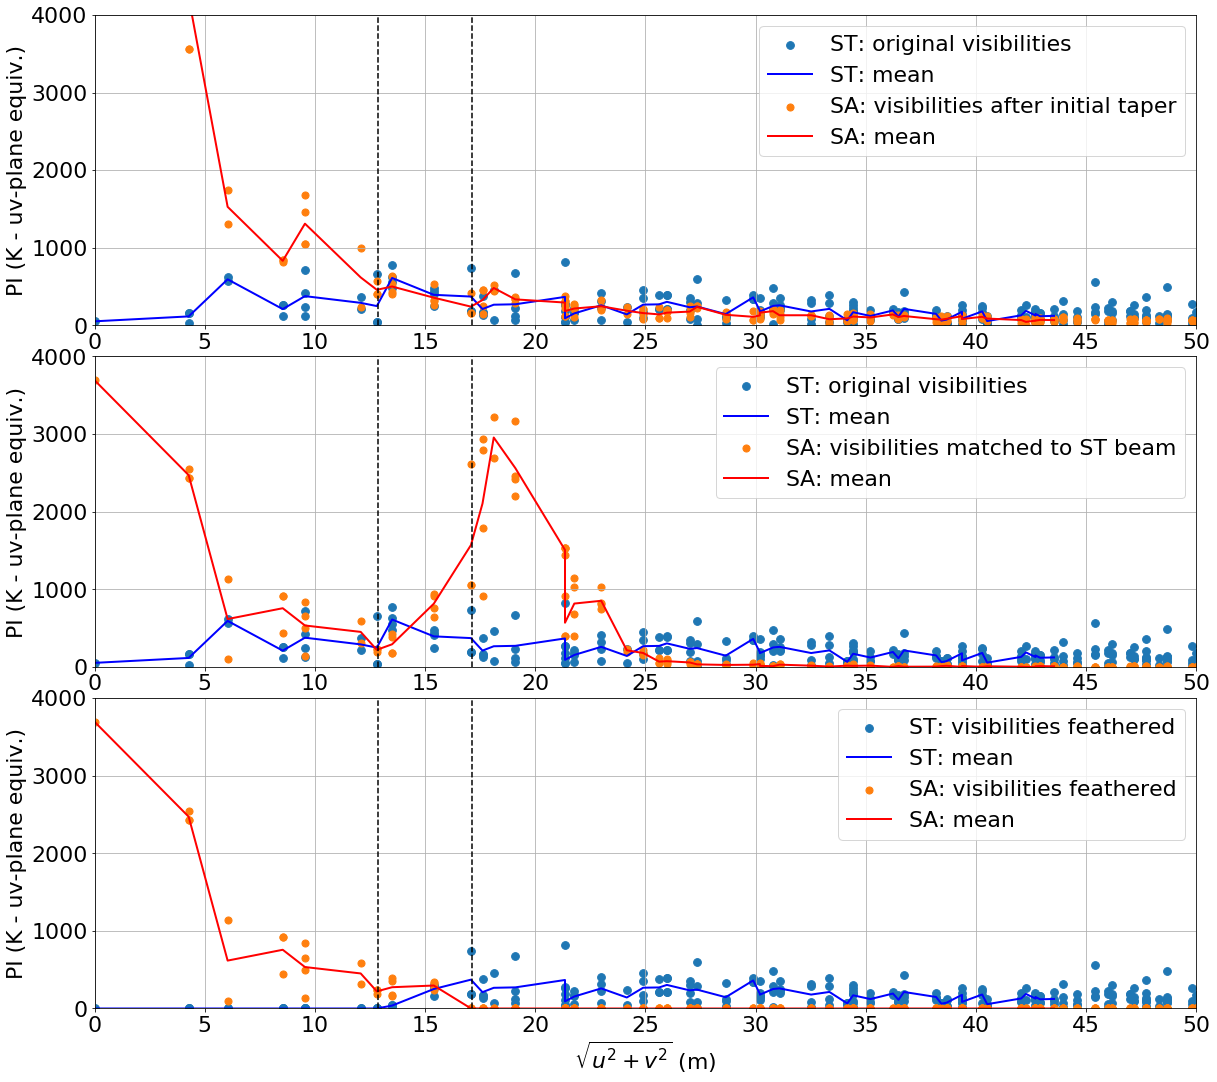

In [6]:
j = 35 # pick which field to plot

fs=22
lw = 2

axs = ['ax1','ax2','ax3']

fig = plt.figure(figsize=(17,15))
plt.subplots_adjust(top = 0.98, bottom = 0.06, right = 0.98, left = 0.08, hspace=0.1)

axs[0] = fig.add_subplot(311)
axs[0].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[0].scatter(radius_G_fields[j],ampl_G_initial[j],s=50,label='SA: visibilities after initial taper')
axs[0].plot(rad_samples[j,:],ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[0].plot(rad_samples[j,:],SA_orig_samples[j],color='red',linewidth=lw,label='SA: mean')
handles,labels = axs[0].get_legend_handles_labels()
order = [2,0,3,1]
axs[0].set_ylim(0,4000)
axs[0].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[1] = fig.add_subplot(312)
axs[1].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[1].scatter(radius_G_fields[j],ampl_G_match[j],s=50,label='SA: visibilities matched to ST beam')
axs[1].plot(rad_samples[j,:],ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[1].plot(rad_samples[j,:],SA_match_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[1].set_ylim(0,4000)
handles,labels = axs[1].get_legend_handles_labels()
order = [2,0,3,1]
axs[1].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[2] = fig.add_subplot(313)
axs[2].set_xlabel('$\sqrt{u^2+v^2}$ (m)',fontsize=fs)
axs[2].scatter(radius_C_fields[j],ampl_C_feath[j],s=60,label='ST: visibilities feathered')
axs[2].scatter(radius_G_fields[j],ampl_G_feath[j],s=50,label='SA: visibilities feathered')
axs[2].plot(rad_samples[j,:],ST_feath_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[2].plot(rad_samples[j,:],SA_feath_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[2].set_ylim(0,4000)
handles,labels = axs[2].get_legend_handles_labels()
order = [2,0,3,1]
axs[2].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

for i in range(0,3):
    axs[i].tick_params(axis="x", labelsize=fs)
    axs[i].tick_params(axis="y", labelsize=fs)
    axs[i].set_xlim(0,50)
    axs[i].set_ylabel('PI (K - uv-plane equiv.)',fontsize=fs)
    axs[i].plot([12.858,12.858],[0,80000],color='black',linestyle='dashed')
    axs[i].plot([17.144,17.144,],[0,80000],color='black',linestyle='dashed')
    axs[i].grid()
    axs[i].set_xticks([0,5,10,15,20,25,30,35,40,45,50])
    #axs[i].set_ticklabels(fontsize=fs)

In [7]:
ratioavg = np.zeros([numfields])

for j in range(0,numfields):
    
    woverlap = np.where((rad_samples[j,:]<16.8) & (rad_samples[j,:]>13.2))
    C_test = ST_orig_samples[j][woverlap]
    G_test = SA_match_samples[j][woverlap]
    #print(C_test)
    #print(G_test)
    avrg = (G_test+C_test)/2.
    #print(avrg)
    ratio = G_test/C_test
    ratioavg[j] = np.mean(ratio)
    #print(j,fieldandband[j],ratio,ratioavg[j])
    print(ratioavg[j])

0.7883496344123062
5.986173666444583
1.1411517210396382
3.106999390341347
0.7571983056991539
2.2065038866207636
1.070665860166509
2.302462143430822
1.0106299750118646
1.6598837168676674
0.965736327148241
1.5537067407611829
0.3756980138645025
1.1993863911098903
0.5882180815306004
1.2114186364006871
4.014949480742061
2.5519900237193673
5.086735197880106
1.7096331525353392
2.506056867225337
1.850743408526754
2.265105746963466
2.328276187247182
4.384996046328565
1.5613818052495296
2.5832994507159235
1.4965257614673089
3.8909375244302824
2.39699564045657
2.1425618354560547
2.5430717889221466
1.8894273418293857
1.4460446017441595
2.052622019930411
1.2733305478308306
2.375369641599688
1.1855832590741437
1.4637417859846624
1.126271702784865
1.9876076336363102
1.586201321378982
3.3789989199860364
1.6649641443870942
1.0821490213949905
1.6814471110090508
1.6436334105429145
1.2431293970000574
3.0894159729063095
1.3142985756120251
1.4917357957647588
1.3006326782063753
1.1260375854111455
1.661488752